---

##  Dataset Description

This dataset is designed to analyze and predict personality traits—specifically whether an individual is more likely to be an **introvert** or an **extrovert**—based on behavioral, social, and psychological patterns. It contains both numerical and categorical variables that represent lifestyle habits and social tendencies.

* **Total Records:** 2,900
* **Target Variable:** `Personality` (Binary: `Introvert` or `Extrovert`)
* **Missing Values:** Present in several columns, handled via imputation

---

##  Feature Summary

| Feature Name                | Type                 | Description                                                                                        |
| --------------------------- | -------------------- | -------------------------------------------------------------------------------------------------- |
| `Time_spent_Alone`          | Numeric              | Average time (possibly in hours or scale) a person spends alone during a typical period            |
| `Stage_fear`                | Binary               | Whether the person experiences fear of speaking or performing in front of an audience (`Yes`/`No`) |
| `Social_event_attendance`   | Numeric              | Frequency of attending social events (higher values = more frequent participation)                 |
| `Going_outside`             | Numeric              | Frequency of going outside or being in public places (social exposure measure)                     |
| `Drained_after_socializing` | Binary               | Whether the person feels emotionally drained after social interaction (`Yes`/`No`)                 |
| `Friends_circle_size`       | Numeric              | Number of people in the person’s close friend group or social circle                               |
| `Post_frequency`            | Numeric              | Frequency of posting on social media or online platforms                                           |
| `Personality`               | Categorical (Target) | Personality classification as either **Introvert** or **Extrovert**                                |

---

# Import Libraries & Load Dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import math
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import warnings
warnings.filterwarnings("ignore")
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/extrovert-vs-introvert-behavior-data/personality_dataset.csv


In [2]:
df = pd.read_csv("/kaggle/input/extrovert-vs-introvert-behavior-data/personality_dataset.csv")

## Display the First 5 Rows

In [3]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


## Dataset Shape (Rows, Columns)

In [4]:
print("\n Dataset Shape (rows, columns):", df.shape)


 Dataset Shape (rows, columns): (2900, 8)


## Show Column Names and Data Types

In [5]:
print(df.dtypes)

Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object


#  Missing Value Analysis & Handling

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


## Check for Missing Values in Each Column

In [7]:
df.isnull().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

## Split Columns by Data Type

In [8]:
numeric_columns = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside',
                   'Friends_circle_size', 'Post_frequency']
binary_columns = ['Stage_fear', 'Drained_after_socializing']


## Map Binary Columns to 0/1 First

In [9]:
binary_map = {'Yes': 1, 'No': 0}
df[binary_columns] = df[binary_columns].replace(binary_map)

##  Impute numeric columns (mean)

In [10]:
num_imputer = SimpleImputer(strategy='mean')
df[numeric_columns] = num_imputer.fit_transform(df[numeric_columns])

## Impute binary columns (mode)

In [11]:
cat_imputer = SimpleImputer(strategy='most_frequent')
df[binary_columns] = cat_imputer.fit_transform(df[binary_columns])

##  Confirm all cleaned

In [12]:
df.isnull().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

# Target Encoding + Scaling + Visual Analysis

##  Encode Target Column (Personality)

In [13]:
le = LabelEncoder()
df["Personality"] = le.fit_transform(df["Personality"]) 

## Define Features and Target

In [14]:
X = df.drop("Personality", axis=1)
y = df["Personality"]

## Scale Features Using StandardScaler

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Reconstruct DataFrame for plotting

In [16]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df["Personality"] = y.values

##  Distribution Plots for All Numeric Features

In [17]:
num_features = len(X.columns)
cols = 3 
rows = math.ceil(num_features / cols)

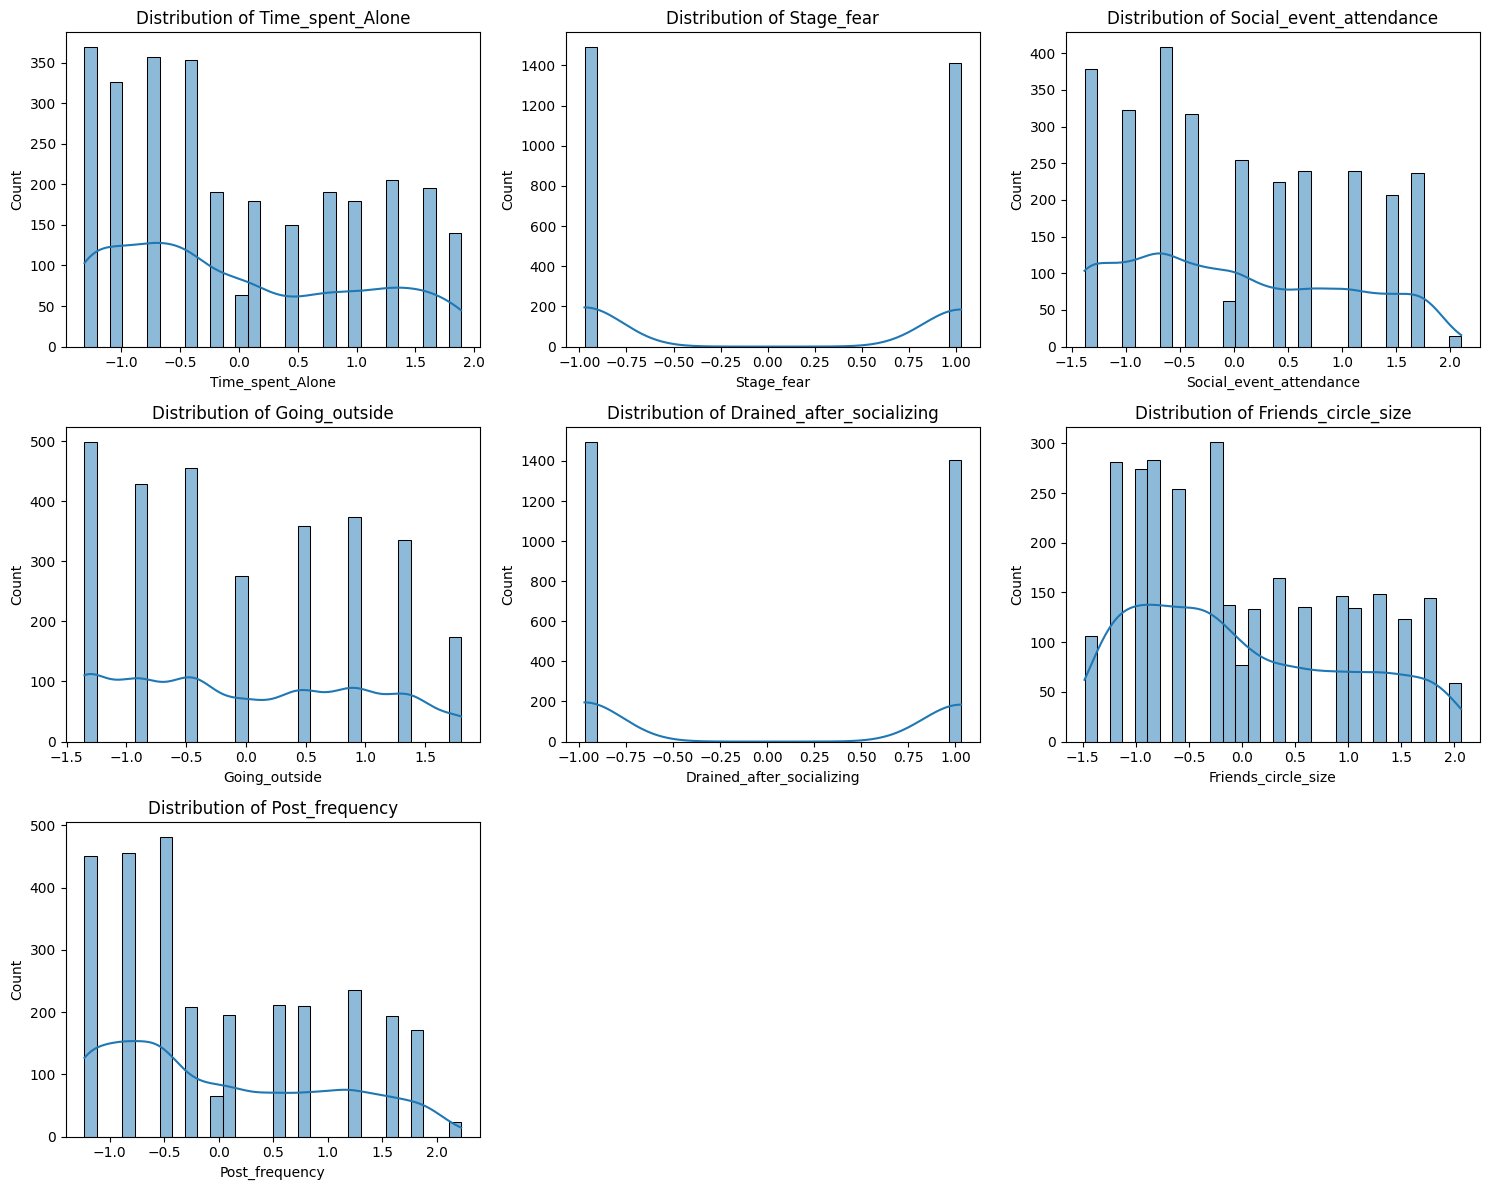

In [18]:
plt.figure(figsize=(5 * cols, 4 * rows))
for i, col in enumerate(X.columns):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(X_scaled_df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
plt.tight_layout()
plt.show()

##  Updated Boxplot by Personality

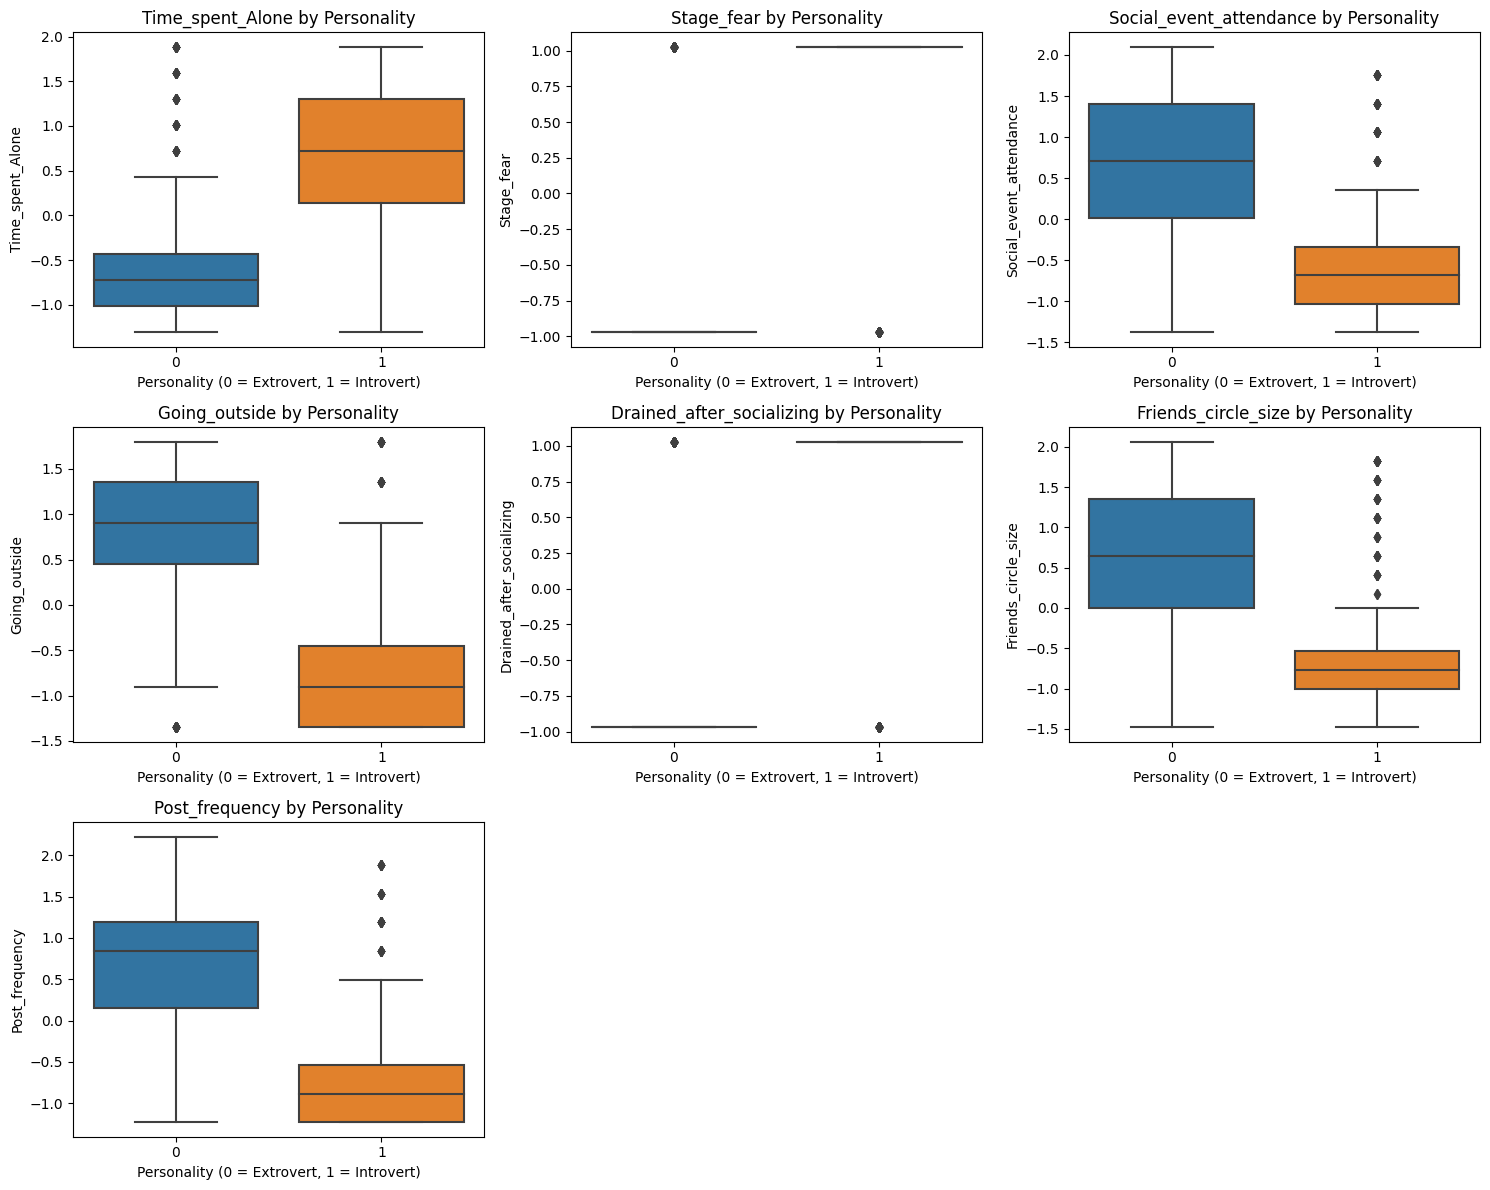

In [19]:
plt.figure(figsize=(5 * cols, 4 * rows))
for i, col in enumerate(X.columns):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x="Personality", y=col, data=X_scaled_df)
    plt.title(f"{col} by Personality")
    plt.xlabel("Personality (0 = Extrovert, 1 = Introvert)")
    plt.ylabel(col)
plt.tight_layout()
plt.show()

##  Correlation Heatmap

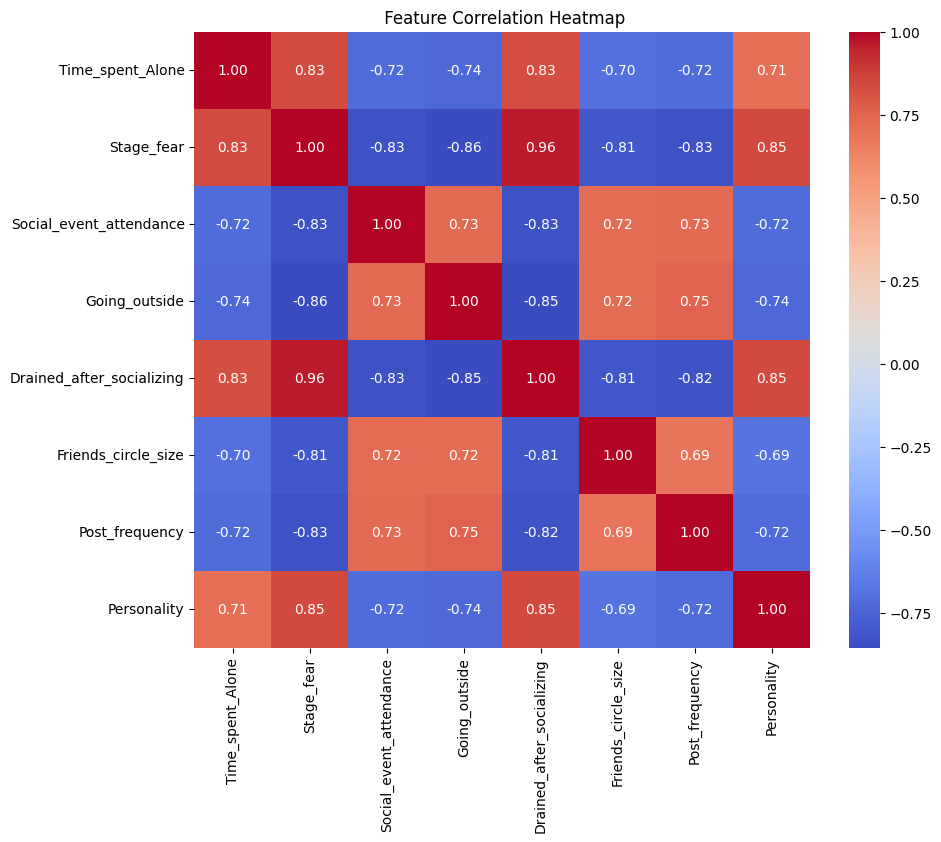

In [20]:
plt.figure(figsize=(10, 8))
corr = X_scaled_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title(" Feature Correlation Heatmap")
plt.show()

# Train ML Models & Evaluate Performance

## Split Data into Train and Test Sets

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=537
)

## Define Models

In [22]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel="rbf", probability=True)
}

## Train, Predict, Evaluate Each Model


 Training: Logistic Regression
 Accuracy: 0.9324

 Classification Report:
               precision    recall  f1-score   support

   Extrovert       0.93      0.94      0.93       373
   Introvert       0.93      0.93      0.93       352

    accuracy                           0.93       725
   macro avg       0.93      0.93      0.93       725
weighted avg       0.93      0.93      0.93       725



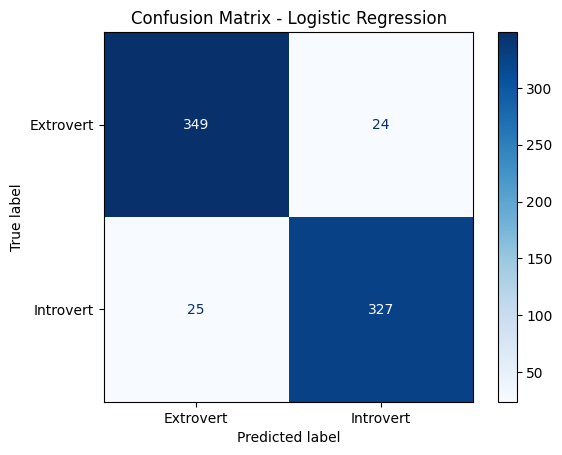

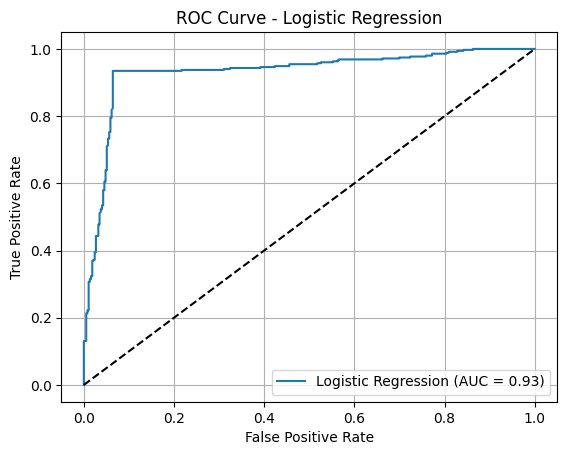


 Training: Random Forest
 Accuracy: 0.9172

 Classification Report:
               precision    recall  f1-score   support

   Extrovert       0.92      0.92      0.92       373
   Introvert       0.92      0.91      0.91       352

    accuracy                           0.92       725
   macro avg       0.92      0.92      0.92       725
weighted avg       0.92      0.92      0.92       725



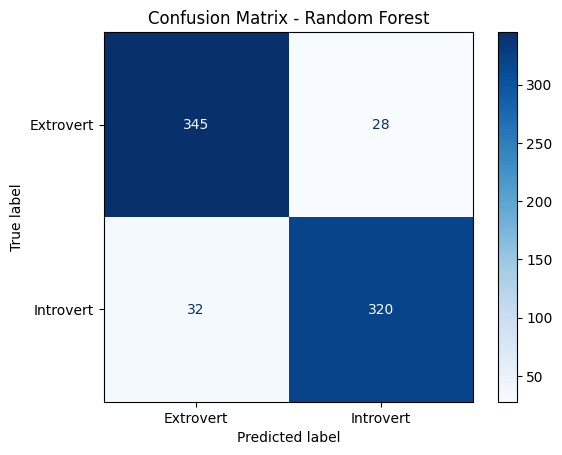

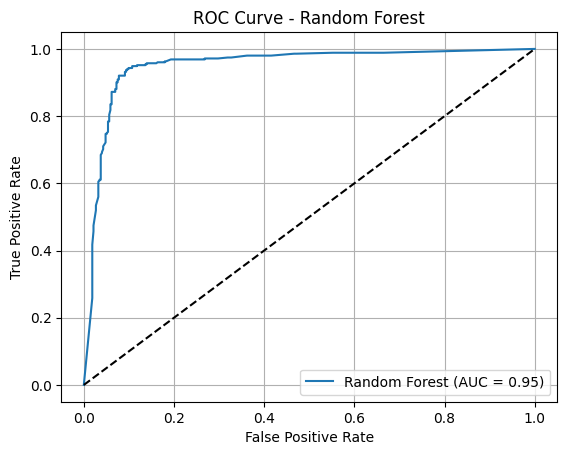


 Training: Support Vector Machine
 Accuracy: 0.9352

 Classification Report:
               precision    recall  f1-score   support

   Extrovert       0.94      0.94      0.94       373
   Introvert       0.93      0.93      0.93       352

    accuracy                           0.94       725
   macro avg       0.94      0.94      0.94       725
weighted avg       0.94      0.94      0.94       725



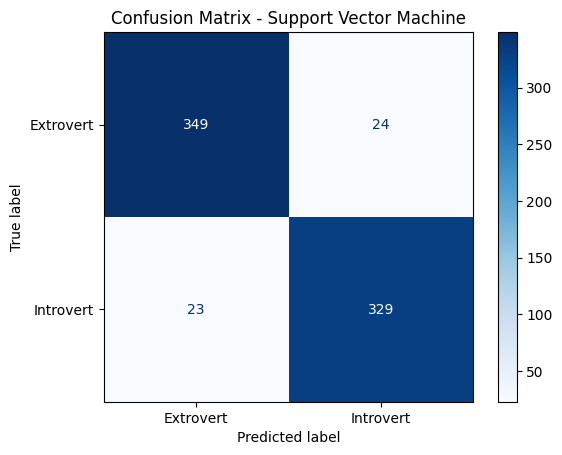

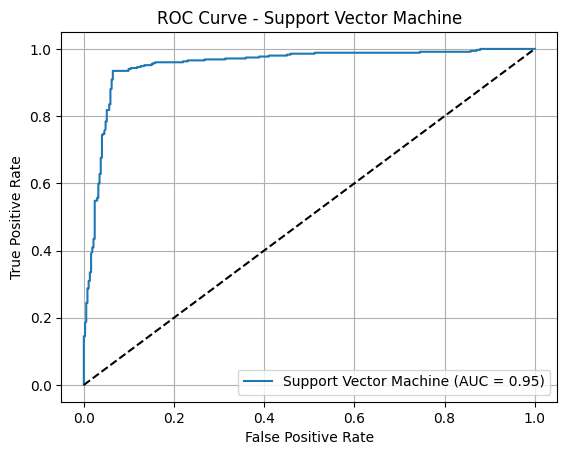

In [23]:
results = {}

for name, model in models.items():
    print(f"\n Training: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    #  Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f" Accuracy: {acc:.4f}")

    #  Classification Report
    print("\n Classification Report:\n", classification_report(y_test, y_pred, target_names=['Extrovert', 'Introvert']))

    #  Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Extrovert', 'Introvert'])
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    #  ROC Curve
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()

## Model Comparison Table

In [24]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
2,Support Vector Machine,0.935172
0,Logistic Regression,0.932414
1,Random Forest,0.917241


---

##  Personality Prediction using Machine Learning

**Objective:** Predict whether a person is an introvert or extrovert based on behavioral and social indicators.

---

###  Step 1: Library Imports & Data Loading

We began by importing the essential libraries such as `pandas`, `numpy`, `matplotlib`, `seaborn`, and several `sklearn` modules. Then, we loaded the dataset from a CSV file. The dataset had 2,900 rows and 8 columns, including the target variable `Personality` (either 'Introvert' or 'Extrovert').

---

###  Step 2: Missing Value Analysis & Handling

We checked for missing values column by column. The dataset contained missing values in both numeric (e.g., `Time_spent_Alone`, `Post_frequency`) and categorical/binary features (e.g., `Stage_fear`, `Drained_after_socializing`).

* Numeric columns were filled using **mean imputation** via `SimpleImputer(strategy='mean')`
* Categorical binary columns ('Yes'/'No') were first converted to 1/0 using `.replace()` and then imputed with **most frequent** values via `SimpleImputer(strategy='most_frequent')`

After imputation, the dataset had no missing values and was ready for transformation.

---

###  Step 3: Target Encoding, Feature Scaling & Visualizations

* The target column `Personality` was label encoded into numerical form (0 for 'Extrovert', 1 for 'Introvert').
* All features were standardized using `StandardScaler` to ensure fair treatment by ML models.
* Then, three major visualizations were performed:

  * **Histogram distributions** of each feature to observe skewness and range
  * **Boxplots** to see how each feature differs between introverts and extroverts
  * A **correlation heatmap** to understand inter-feature relationships

These visualizations helped uncover trends such as:

* Introverts tend to spend more time alone and attend fewer social events.
* Some features had mild correlations but no extreme multicollinearity.

---

###  Step 4: Model Training, Evaluation & Comparison

We trained three popular classification models:

1. **Logistic Regression**
2. **Random Forest Classifier**
3. **Support Vector Machine (SVM)**

For each model, the following evaluations were done:

* **Accuracy Score** to measure correct predictions
* **Classification Report** with precision, recall, and F1-score
* **Confusion Matrix** to show prediction breakdown
* **ROC Curve** with AUC score to evaluate true/false positive rates visually

Each model showed different performance levels. The final accuracy comparison was printed as a sorted table to highlight the best model.

---

###  Final Outcome

The pipeline successfully:

* Cleaned and prepared the dataset
* Visualized distributions and patterns
* Built and evaluated multiple models
* Identified key behavior patterns separating introverts from extroverts

This project serves as a complete end-to-end ML workflow: from preprocessing to modeling to evaluation, built in a modular and interpretable way.

---

# Thank you for taking the time to review my work. I would be very happy if you like the project! 😊

--- 